# Google Merchandise Store — Product Analytics

**Portfolio project:** BigQuery SQL + Python analysis of the public Google Analytics Sample dataset.

### Business questions
1. Where are the largest losses in the e-commerce funnel?
2. Does purchase conversion differ by device?
3. Is the device gap explained only by new vs returning user mix?
4. Which acquisition channels combine traffic volume with strong conversion?
5. How quickly do cohorts return after their first observed visit?
6. Which observed issue would be a good candidate for a controlled experiment?

> All results are observational unless explicitly labeled as experiment design.


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

pd.set_option("display.max_columns", 50)


## 1. Dataset overview and data quality

In [2]:
profile = pd.read_csv("../data/profile.csv")
quality = pd.read_csv("../data/data_quality.csv")
profile

,min_date,max_date,sessions,unique_users,sessions_with_purchase,transactions
0,2016-08-01,2017-08-01,903653,714167,11552,12115


In [3]:
quality

,rows_total,unique_session_keys,duplicate_rows,repeated_visitor_visit_keys,extra_rows_under_visitor_visit_key,repeated_keys_with_different_start_time,repeated_keys_with_different_date
0,903653,903653,0,898,898,898,898


**Data-quality conclusion**

- The dataset contains **903,653 session rows** and **714,167 unique users**.
- The composite `(fullVisitorId, visitId, visitStartTime)` is unique for every row.
- `fullVisitorId + visitId` repeats in 898 cases, but each repeated pair has a different date and start time; these rows are therefore retained as distinct sessions.
- Raw BigQuery data are not committed to the repository; only compact aggregated outputs are stored in `data/`.


## 2. E-commerce funnel

In [4]:
funnel = pd.read_csv("../data/funnel.csv")
funnel

,step,stage,sessions,conversion_from_start_pct,conversion_from_previous_pct,dropoff_from_previous_pct
0,1,All sessions,903653,100.00,NaN,NaN
1,2,Product view,124188,13.74,13.74,86.26
2,3,Add to cart,50139,5.55,40.37,59.63
3,4,Checkout,22407,2.48,44.69,55.31
4,5,Purchase,11552,1.28,51.56,48.44


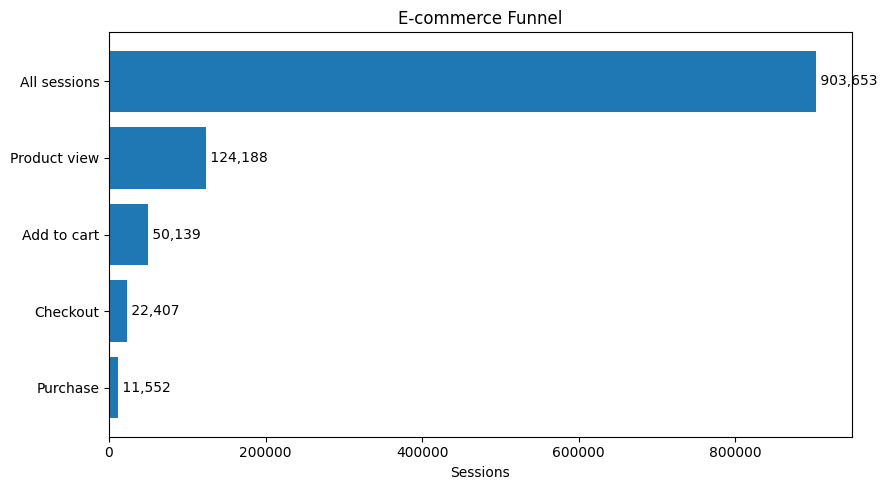

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(funnel["stage"], funnel["sessions"])
ax.invert_yaxis()
ax.set_xlabel("Sessions")
ax.set_title("E-commerce Funnel")
for i, v in enumerate(funnel["sessions"]):
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout()
plt.show()


**Finding:** overall session → purchase conversion is about **1.28%**.  
Within the product funnel, the largest loss is **Product view → Add to cart**: roughly **59.6% drop-off**.


## 3. Device segmentation

In [6]:
device = pd.read_csv("../data/device_funnel.csv")
device

,device_category,sessions,product_views,add_to_carts,checkouts,purchases,product_view_rate_pct,cart_from_view_pct,checkout_from_cart_pct,purchase_from_checkout_pct,session_to_purchase_pct
0,desktop,664479,94699,40493,19344,10528,14.25,42.76,47.77,54.43,1.58
1,mobile,208725,25843,8388,2677,856,12.38,32.46,31.91,31.98,0.41
2,tablet,30449,3646,1258,386,168,11.97,34.50,30.68,43.52,0.55
3,ALL,903653,124188,50139,22407,11552,13.74,40.37,44.69,51.56,1.28


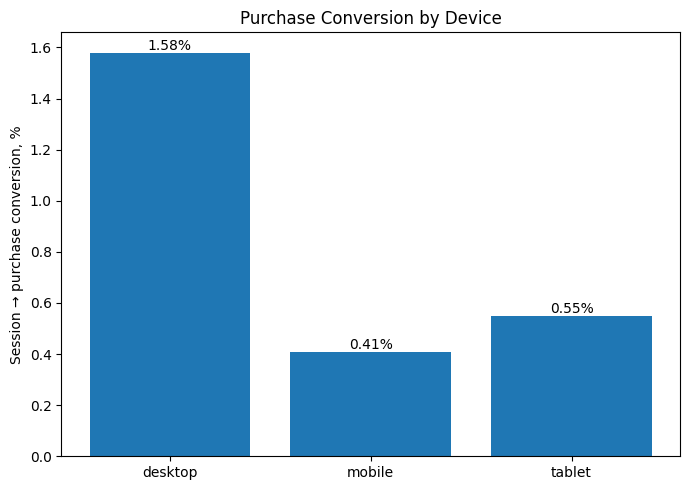

In [7]:
plot_df = device[device["device_category"] != "ALL"].copy()
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(plot_df["device_category"], plot_df["session_to_purchase_pct"])
ax.set_ylabel("Session → purchase conversion, %")
ax.set_title("Purchase Conversion by Device")
for bar, val in zip(bars, plot_df["session_to_purchase_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, val, f"{val:.2f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()


**Finding:** desktop session → purchase conversion is **1.58%**, compared with **0.41%** on mobile and **0.55%** on tablet.  
The gap appears at multiple lower-funnel stages, not only at purchase.


## 4. New vs returning users

In [8]:
user_type = pd.read_csv("../data/user_type_device.csv")
user_type

,user_type,device_category,sessions,purchases,purchase_conversion_pct
0,new,desktop,513438,3902,0.76
1,new,mobile,165461,478,0.29
2,new,tablet,24161,95,0.39
3,returning,desktop,151041,6626,4.39
4,returning,mobile,43264,378,0.87
5,returning,tablet,6288,73,1.16


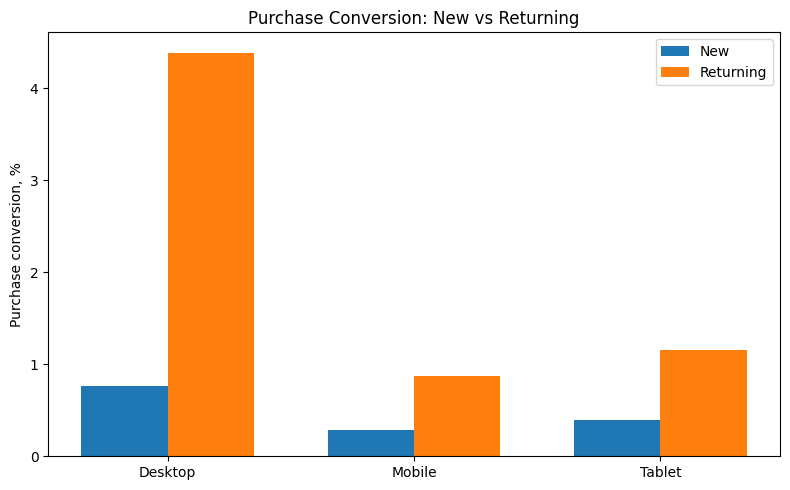

In [9]:
pivot = user_type.pivot(index="device_category", columns="user_type", values="purchase_conversion_pct").loc[
    ["desktop", "mobile", "tablet"]
]
x = np.arange(len(pivot.index))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, pivot["new"], width, label="New")
ax.bar(x + width/2, pivot["returning"], width, label="Returning")
ax.set_xticks(x)
ax.set_xticklabels(["Desktop", "Mobile", "Tablet"])
ax.set_ylabel("Purchase conversion, %")
ax.set_title("Purchase Conversion: New vs Returning")
ax.legend()
plt.tight_layout()
plt.show()


**Finding:** returning users convert substantially better than new users on every device.  
However, the desktop–mobile gap persists **within both user types**, so the aggregate device gap is not explained only by different new/returning mix.


## 5. Acquisition channels

In [10]:
channels = pd.read_csv("../data/channel_performance.csv")
channels

,channel,sessions,purchases,traffic_share_pct,purchase_conversion_pct,purchase_share_pct
0,Organic Search,381561,3443,42.22,0.90,29.80
1,Social,226117,104,25.02,0.05,0.90
2,Direct,143026,2061,15.83,1.44,17.84
3,Referral,104838,5322,11.60,5.08,46.07
4,Paid Search,25326,469,2.80,1.85,4.06
5,Affiliates,16403,9,1.82,0.05,0.08
6,Display,6262,143,0.69,2.28,1.24
7,(Other),120,1,0.01,0.83,0.01


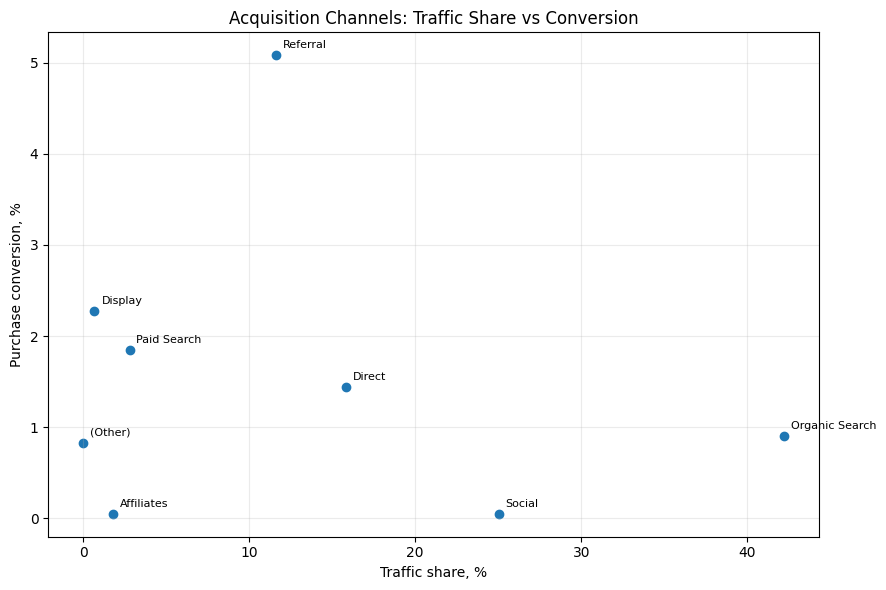

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(channels["traffic_share_pct"], channels["purchase_conversion_pct"])
for _, row in channels.iterrows():
    ax.annotate(
        row["channel"],
        (row["traffic_share_pct"], row["purchase_conversion_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )
ax.set_xlabel("Traffic share, %")
ax.set_ylabel("Purchase conversion, %")
ax.set_title("Acquisition Channels: Traffic Share vs Conversion")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


**Finding:** Referral has the highest purchase conversion (**5.08%**) and generates about **46% of purchases** while accounting for only **11.6% of sessions**.  
Social contributes **25.0% of sessions** but converts at only **0.05%**.

This does **not** prove channel profitability: acquisition cost, revenue and campaign intent are required for a full efficiency assessment.


## 6. Cohort retention

In [12]:
retention = pd.read_csv("../data/retention.csv", parse_dates=["cohort_month"])
retention.head()

,cohort_month,cohort_size,month_number,active_users,retention_pct
0,2016-08-01,61699,0,61699,100.00
1,2016-08-01,61699,1,2640,4.28
2,2016-08-01,61699,2,1176,1.91
3,2016-08-01,61699,3,634,1.03
4,2016-08-01,61699,4,473,0.77


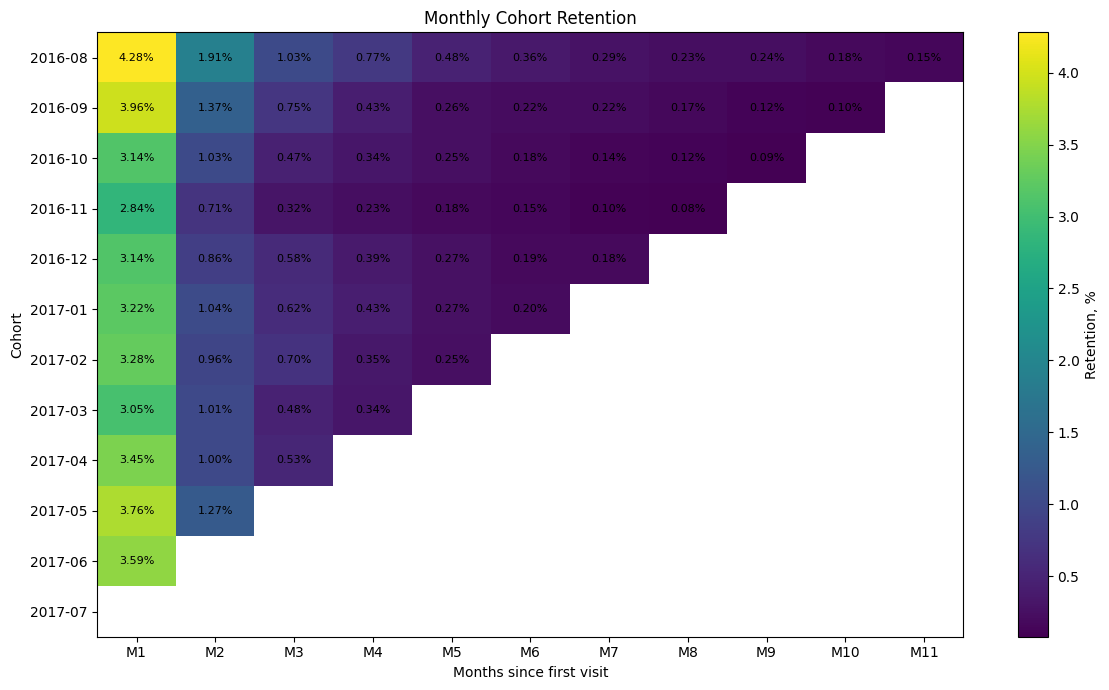

In [13]:
heat = retention.pivot(index="cohort_month", columns="month_number", values="retention_pct")
heat.index = heat.index.strftime("%Y-%m")
heat = heat.loc[:, [c for c in heat.columns if c > 0]]

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(heat.values, aspect="auto")
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels([f"M{c}" for c in heat.columns])
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xlabel("Months since first visit")
ax.set_ylabel("Cohort")
ax.set_title("Monthly Cohort Retention")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}%", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Retention, %")
plt.tight_layout()
plt.show()


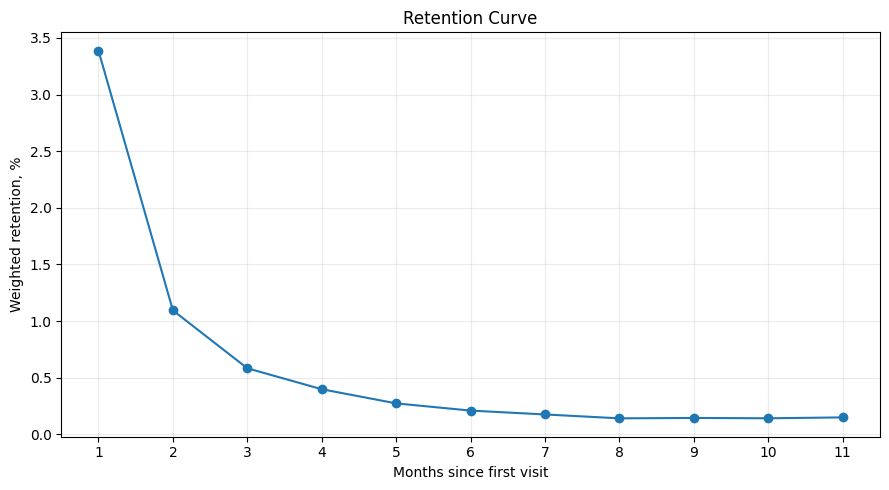

,month_number,active_users,cohort_size,retention_pct
0,1,22261,657154,3.387486
1,2,6657,608481,1.094036
2,3,3263,559825,0.582861
3,4,2019,507401,0.397910
4,5,1235,452692,0.272812


In [14]:
weighted = (
    retention[retention["month_number"] > 0]
    .groupby("month_number")
    .agg(active_users=("active_users", "sum"), cohort_size=("cohort_size", "sum"))
    .reset_index()
)
weighted["retention_pct"] = 100 * weighted["active_users"] / weighted["cohort_size"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(weighted["month_number"], weighted["retention_pct"], marker="o")
ax.set_xticks(weighted["month_number"])
ax.set_xlabel("Months since first visit")
ax.set_ylabel("Weighted retention, %")
ax.set_title("Retention Curve")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

weighted.head(5)


**Finding:** weighted retention falls from **3.39% at M1** to **1.09% at M2** and **0.58% at M3**.  
M1 retention across cohorts ranges from **2.84% to 4.28%**.


## 7. Statistical comparison: desktop vs mobile

In [15]:
desktop_purchases, desktop_sessions = 10528, 664479
mobile_purchases, mobile_sessions = 856, 208725

count = np.array([desktop_purchases, mobile_purchases])
nobs = np.array([desktop_sessions, mobile_sessions])

z_stat, p_value = proportions_ztest(count, nobs)

desktop_cr = desktop_purchases / desktop_sessions
mobile_cr = mobile_purchases / mobile_sessions
diff = desktop_cr - mobile_cr

# Unpooled Wald CI for the absolute difference
se_diff = math.sqrt(
    desktop_cr * (1 - desktop_cr) / desktop_sessions
    + mobile_cr * (1 - mobile_cr) / mobile_sessions
)
ci_low = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

pd.DataFrame([{
    "desktop_cr_pct": desktop_cr * 100,
    "mobile_cr_pct": mobile_cr * 100,
    "absolute_difference_pp": diff * 100,
    "conversion_ratio": desktop_cr / mobile_cr,
    "z_statistic": z_stat,
    "p_value": p_value,
    "ci_95_low_pp": ci_low * 100,
    "ci_95_high_pp": ci_high * 100
}]).round(4)


,desktop_cr_pct,mobile_cr_pct,absolute_difference_pp,conversion_ratio,z_statistic,p_value,ci_95_low_pp,ci_95_high_pp
0,1.5844,0.4101,1.1743,3.8634,41.2577,0.0,1.1336,1.2149


The observed difference is statistically significant, but this is **not an A/B test**.  
Device groups were not randomized, so statistical significance does not establish a causal effect of device type.


## 8. Proposed A/B test

In [16]:
baseline = 0.3246          # mobile product view -> add to cart
target = 0.3746            # +5 percentage points
alpha = 0.05
power = 0.80

effect_size = abs(proportion_effectsize(baseline, target))
n_per_group = math.ceil(
    NormalIndPower().solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=power,
        ratio=1,
        alternative="two-sided"
    )
)
buffered_per_group = math.ceil(n_per_group * 1.10)

pd.DataFrame([{
    "baseline_pct": baseline * 100,
    "target_pct": target * 100,
    "mde_pp": (target - baseline) * 100,
    "n_per_group": n_per_group,
    "n_per_group_with_10pct_buffer": buffered_per_group,
    "total_with_buffer": 2 * buffered_per_group
}])


,baseline_pct,target_pct,mde_pp,n_per_group,n_per_group_with_10pct_buffer,total_with_buffer
0,32.46,37.46,5.0,1427,1570,3140


**Experiment proposal:** test a redesigned mobile product page (for example, a more prominent/sticky Add-to-cart CTA and clearer variant selection).

- Primary metric: mobile Product view → Add to cart conversion
- Baseline: **32.46%**
- MDE: **+5 p.p.**
- α = 0.05, power = 80%
- Required nominal sample: about **1,427 per group**
- With 10% buffer: about **1,570 per group / 3,140 total**
- Historical eligible volume suggests roughly **45 days** at the sample's average traffic level

Full design: [`docs/experiment_design.md`](../docs/experiment_design.md)


## 9. Conclusions and limitations

### Conclusions
- The largest internal funnel loss occurs before Add to cart.
- Mobile conversion is materially lower than desktop conversion.
- The device gap persists after splitting users into new and returning segments.
- Referral traffic combines high conversion with a meaningful share of purchases.
- Retention declines sharply after the first observed month.
- A mobile product-page experiment is a plausible next step because the observed Product view → Add to cart gap is large and the event volume is sufficient for a feasible test design.

### Limitations
- Public anonymized sample; findings may not represent the current store.
- Observational segment comparisons are not causal.
- Retention uses first **observed** visit in the available window, creating left-censoring risk for the earliest cohort.
- Cohorts have unequal follow-up windows.
- Channel conversion alone is not marketing ROI; cost/revenue context is missing.
- The proposed A/B test is a design only, not a completed experiment.
